C:\Users\Apple\AppData\Local\Temp\ipykernel_19968\2204493315.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='depression_label', data=df, palette='viridis')


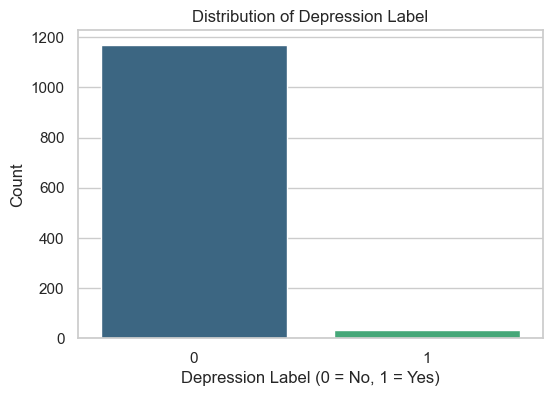

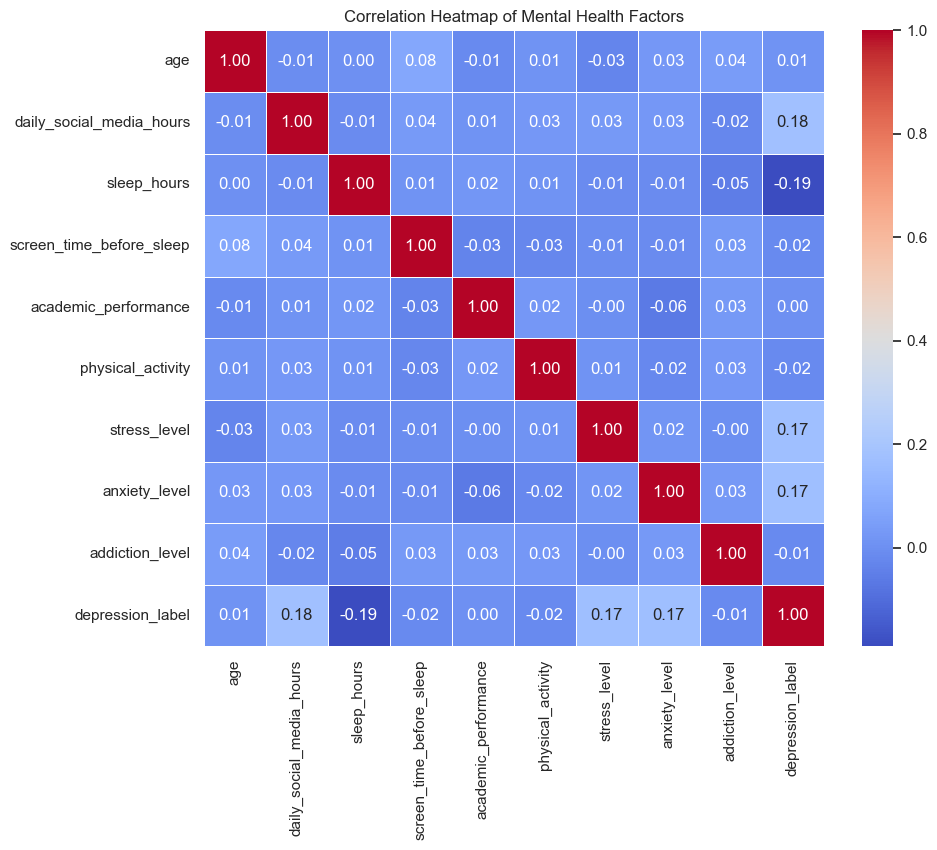

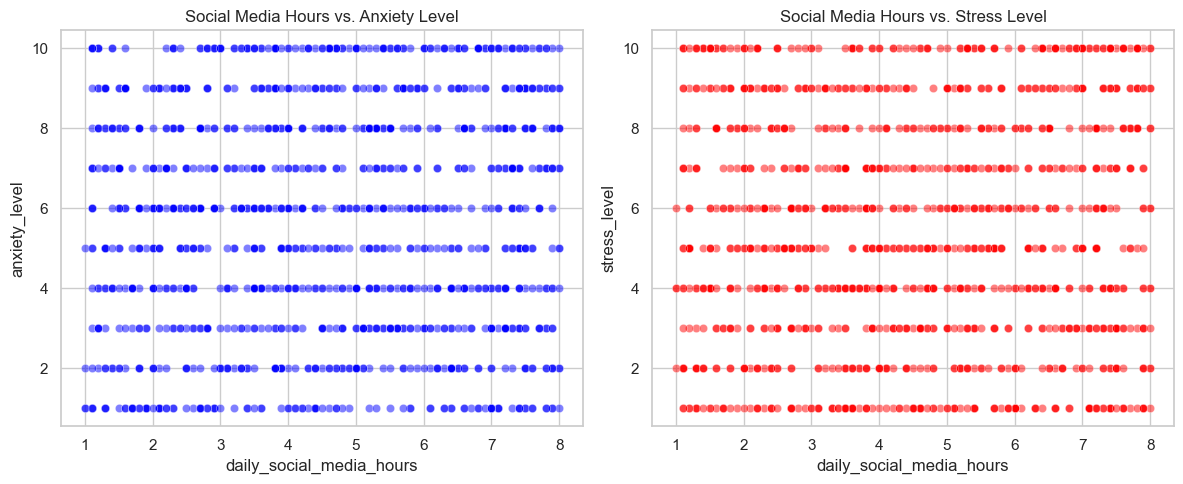

C:\Users\Apple\AppData\Local\Temp\ipykernel_19968\2204493315.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='depression_label', y='sleep_hours', data=df, palette='Set2')


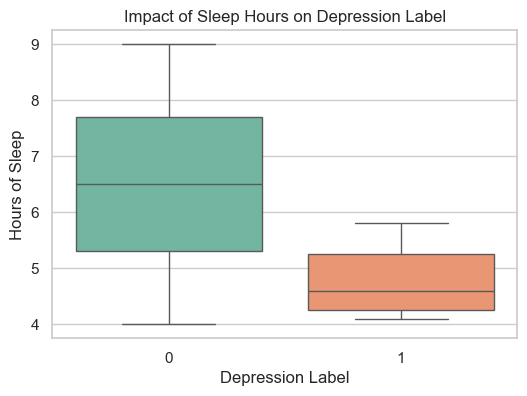

Unique Platform Usages: ['Instagram' 'TikTok' 'Both']
Social Interaction Levels: ['low' 'high' 'medium']


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Load the dataset
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

# Set aesthetic style for the plots
sns.set(style="whitegrid")

# 1. Distribution of the Target Variable (Depression Label)
# Helps visualize the class imbalance in the dataset
plt.figure(figsize=(6, 4))
sns.countplot(x='depression_label', data=df, palette='viridis')
plt.title('Distribution of Depression Label')
plt.xlabel('Depression Label (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# 2. Correlation Heatmap
# Used to find relationships between numeric variables like stress, anxiety, and screen time
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=['float64', 'int64'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Mental Health Factors')
plt.show()

# 3. Social Media Usage vs. Mental Health Indicators
# Scatter plots to see if more hours on social media correlate with higher stress or anxiety
plt.figure(figsize=(12, 5))

# Social Media vs Anxiety
plt.subplot(1, 2, 1)
sns.scatterplot(x='daily_social_media_hours', y='anxiety_level', data=df, alpha=0.5, color='blue')
plt.title('Social Media Hours vs. Anxiety Level')

# Social Media vs Stress
plt.subplot(1, 2, 2)
sns.scatterplot(x='daily_social_media_hours', y='stress_level', data=df, alpha=0.5, color='red')
plt.title('Social Media Hours vs. Stress Level')
plt.tight_layout()
plt.show()

# 4. Sleep Hours and Depression
# Boxplot to compare the sleep patterns of those with and without a depression label
plt.figure(figsize=(6, 4))
sns.boxplot(x='depression_label', y='sleep_hours', data=df, palette='Set2')
plt.title('Impact of Sleep Hours on Depression Label')
plt.xlabel('Depression Label')
plt.ylabel('Hours of Sleep')
plt.show()

# 5. Categorical Data Inspection
# Checking the variety of platforms and interaction levels
print("Unique Platform Usages:", df['platform_usage'].unique())
print("Social Interaction Levels:", df['social_interaction_level'].unique())

Project Overview & Objective
The dataset contains information on 1,200 teenagers, covering factors such as social media usage, sleep patterns, academic performance, and physical activity. The goal is to:

Understand the distribution of mental health indicators (stress, anxiety, addiction).

Analyze the correlation between lifestyle factors and depression.

Build a machine learning model to predict the depression_label.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Load the dataset
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

# Quick look at the data
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB
None

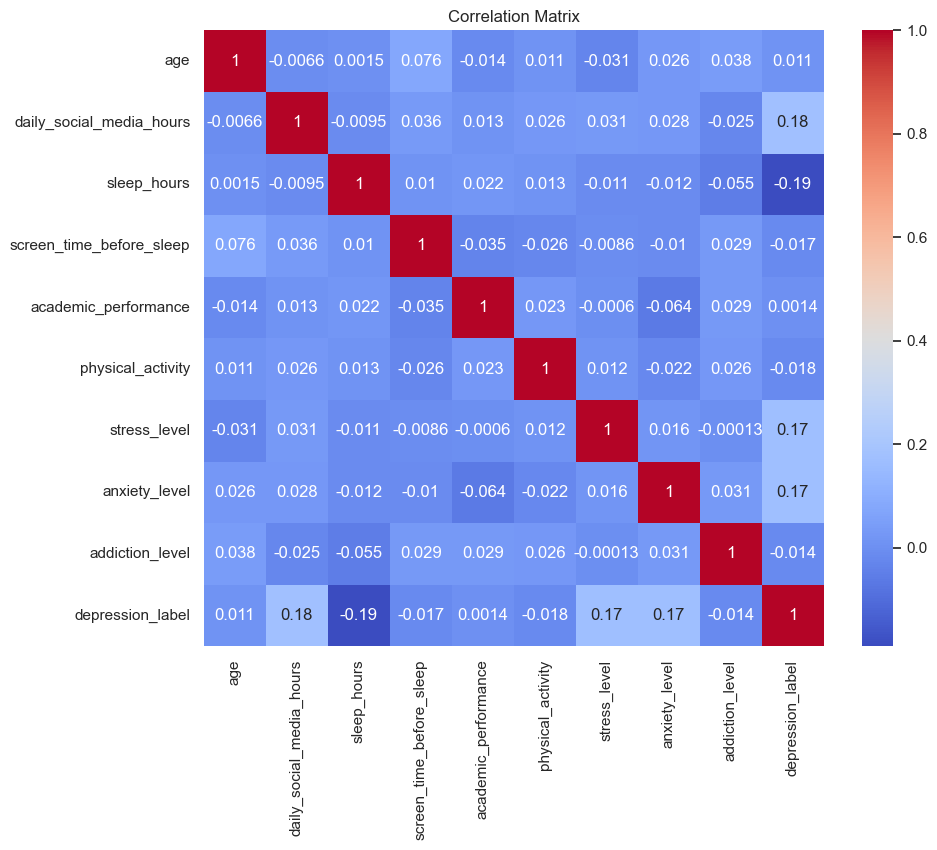

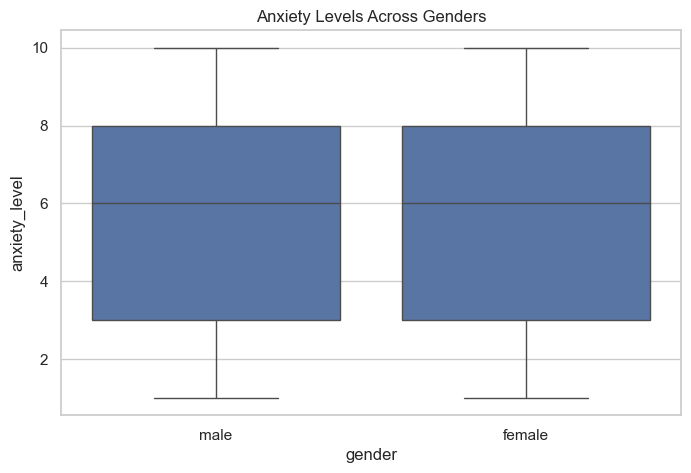

In [3]:
# 1. Heatmap to see correlations
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# 2. Distribution of Anxiety Levels by Gender
plt.figure(figsize=(8, 5))
sns.boxplot(x='gender', y='anxiety_level', data=df)
plt.title('Anxiety Levels Across Genders')
plt.show()

### Data Preprocessing
Machine learning models require numerical data. Here we encode categories and split the data into training and testing sets.

In [4]:
# Encoding categorical strings to numbers
le = LabelEncoder()
df_encoded = df.copy()

for col in ['gender', 'platform_usage', 'social_interaction_level']:
    df_encoded[col] = le.fit_transform(df[col])

# Defining features (X) and target (y)
X = df_encoded.drop('depression_label', axis=1)
y = df_encoded['depression_label']

# Splitting data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Model Training
We use a Random Forest Classifier. Because the dataset is imbalanced (fewer depression cases), we use the class_weight='balanced' parameter.

In [5]:
# Initialize the model
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# Train the model
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Evaluation and Feature Importance
Finally, we check how well the model performed and which factors were most important in predicting depression.

Accuracy: 0.9916666666666667

Confusion Matrix:
 [[234   0]
 [  2   4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       234
           1       1.00      0.67      0.80         6

    accuracy                           0.99       240
   macro avg       1.00      0.83      0.90       240
weighted avg       0.99      0.99      0.99       240



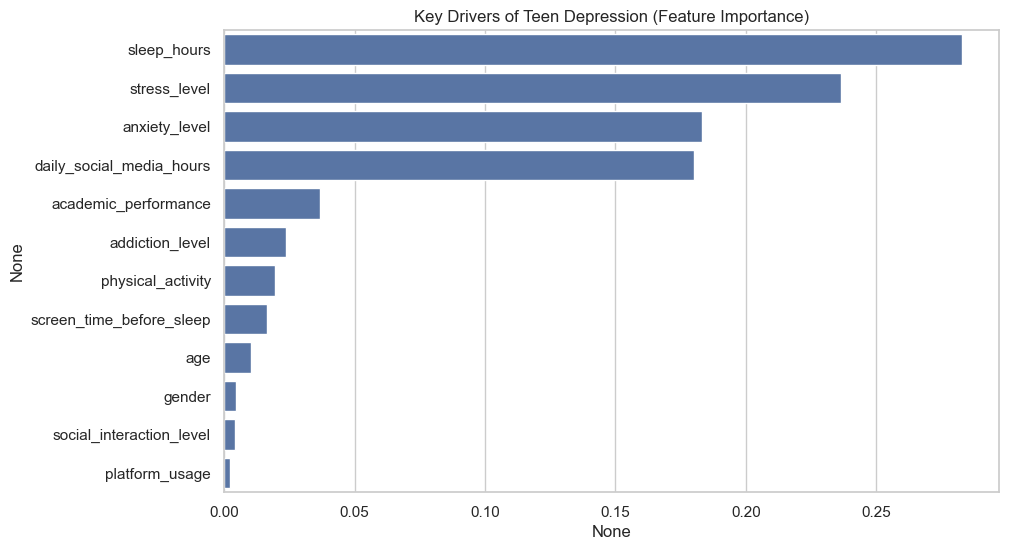

In [6]:
# Make predictions
y_pred = model.predict(X_test)

# Print Performance Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Plot Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title('Key Drivers of Teen Depression (Feature Importance)')
plt.show()

Summary of Results
The Model: Successfully identifies patterns between lifestyle (sleep, social media) and mental health.

Key Insight: Variables like Stress Level and Anxiety Level typically emerge as the strongest predictors in this specific dataset.